In [13]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

In [11]:
station = "Manhattan"
start = "2017-01-01 00:00:00"
end = "2018-12-31 23:00:00"
interval = "hour"
variables = ["TEMP2MAVG","RELHUM2MAVG","SRAVG","WSPD2MAVG","PRECIP",
             "SOILKA5CM","SOILKA10CM","SOILKA20CM","SOILKA50CM",
             "SOILEC5CM","SOILEC10CM","SOILEC20CM","SOILEC50CM",
             "SOILTMP5AVG655","SOILTMP10AVG655","SOILTMP20AVG655","SOILTMP50AVG655"]

In [12]:
if interval == 'day':
    delta = pd.Timedelta('1day')

elif interval == 'hour':
    delta = pd.Timedelta('1hour')

elif interval == '5min':
    delta = pd.Timedelta('5min')
    
start = pd.to_datetime(start)
end = pd.to_datetime(end)
full_period = pd.date_range(start=start, end=end, freq=delta)  
   
# Initialize the Dataframe
df_master = pd.DataFrame({"TIMESTAMP":full_period}) 
df_master.set_index("TIMESTAMP", inplace=True)

# Preallocate other variables with NaNs
for var in variables:
    df_master[var] = np.nan

# Initialize request date.
start_request = start
max_records = 3_000
fmt = '%Y%m%d%H%M%S' 

max_retries = 3
attempt = 0

while start_request <= end:

    # API input parameters
    end_request = start_request + pd.Timedelta(delta) * max_records
    end_request = np.minimum(end_request, end)
    variables_str = ','.join(variables)
    url = f"http://mesonet.k-state.edu/rest/stationdata/?stn={station}&int={interval}&t_start={start_request.strftime(fmt)}&t_end={end_request.strftime(fmt)}&vars={variables_str}"
    url = url.replace(" ", "%20") # replace space with %20
    
    # Temporaty Dataframe with data from current request
    while attempt < max_retries:
        try:
            print(f'Requesting {start_request} to {end_request}')
            df_temp = pd.read_csv(url, na_values="M", parse_dates=["TIMESTAMP"])
            break
        except Exception as e:
            print("Previous call failed. Attempting again...")
            attempt += 1
            if attempt >= max_retries:
                raise RuntimeError(f"Number of attempts exhausted.")

            # If attempting again, delay call for a couple of seconds.
            time.sleep(2)
           
    # Align and update only the returned variables
    df_temp.set_index("TIMESTAMP", inplace=True)
    for col in df_temp.columns:
        if col in df_master.columns:
            df_master.loc[df_temp.index, col] = df_temp[col]
            
    # Update start request date
    start_request = end_request + pd.Timedelta(delta)
    
    # Sleep for 1 second to be nice to the mesonet server
    time.sleep(1)


Requesting 2017-01-01 00:00:00 to 2017-05-06 00:00:00
Requesting 2017-05-06 01:00:00 to 2017-09-08 01:00:00
Requesting 2017-09-08 02:00:00 to 2018-01-11 02:00:00
Requesting 2018-01-11 03:00:00 to 2018-05-16 03:00:00
Requesting 2018-05-16 04:00:00 to 2018-09-18 04:00:00
Requesting 2018-09-18 05:00:00 to 2018-12-31 23:00:00


In [14]:
df_master.reset_index(inplace=True)

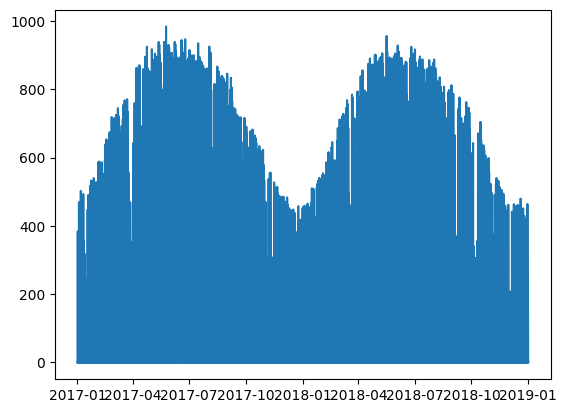

In [15]:
plt.plot(df_master['TIMESTAMP'], df_master['SRAVG'])